## Term Paper - Winter Semester 25/26 Submission

#### **Research Topic: Is Attention All You Need in Low-Resource Settings? An empirical study of self attention integrated with BiLSTM vs Transformers for a low resource language; Swahili.**

In [ ]:
# !pip install evaluate

In [24]:
from google.colab import drive
drive.mount('/content/drive')

# Search entire Drive for the notebook
!find /content/drive/MyDrive -name "swahili_classification.ipynb" 2>/dev/null

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/swahili_classification.ipynb


In [28]:
from google.colab import userdata

# 1. Authenticate
pat = userdata.get('GITHUB_PAT')
!git config --global user.email "cmcayo4@gmail.com"
!git config --global user.name "muchemicarol"

# 2. Clone using PAT in URL
# !git clone https://{pat}@github.com/muchemicarol/ML4NLU_TermPaper.git
%cd /content/ML4NLU_TermPaper

# 3. Copy notebook from Colab's working directory into the repo
!cp /content/drive/MyDrive/Colab Notebooks/swahili_classification.ipynb

# 4. Commit and push
!git add swahili_classification.ipynb
!git commit -m "successful - afriberta tokenization and data loader"
!git push -u origin master        # use 'master' if your branch is master

/content/ML4NLU_TermPaper
cp: cannot stat '/content/drive/MyDrive/Colab': No such file or directory
On branch master
Your branch is up to date with 'origin/master'.

nothing to commit, working tree clean
Branch 'master' set up to track remote branch 'master' from 'origin'.
Everything up-to-date


In [21]:
!git status

On branch master
Your branch is up to date with 'origin/master'.

nothing to commit, working tree clean


In [14]:
# # Delete the entire nested mess
# !rm -rf /content/ML4NLU_TermPaper
# %cd /content

/content


In [ ]:
import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, TrainingArguments, AutoModelForSequenceClassification
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

pd.set_option("display.max_colwidth", None)

In [ ]:
holdout_train = pd.read_csv("Swahili_News_Train.csv")
holdout_test = pd.read_csv("Swahili_News_Test.csv")

print(f"Validate train column names: {holdout_train.columns},\nValidate test column names: {holdout_test.columns}")

Validate train column names: Index(['id', 'content', 'category'], dtype='object'),
Validate test column names: Index(['swahili_id', 'content'], dtype='object')


In [ ]:
swahili_news = pd.read_csv("SwahiliNewsClassificationDataset.csv", nrows=3000)
# swahili_news.head()

In [ ]:
# holdout_train.head(1)

In [ ]:
print(
    f"Training set has {swahili_news.shape[0]} rows while validation/developer set has {holdout_train.shape[0]} rows."
    )

Training set has 3000 rows while validation/developer set has 5151 rows.


In [ ]:
print(
    f"Categories in training but missing in validation: {set(swahili_news["category"].str.lower().unique()) - set(holdout_train["category"].str.lower().unique())}"
    )

Categories in training but missing in validation: {'afya', 'uchumi'}


In [ ]:
print(
    f"Categories in validation but missing in training: {set(holdout_train["category"].str.lower().unique()) - set(swahili_news["category"].str.lower().unique())}"
    )

Categories in validation but missing in training: {'biashara'}


In [ ]:
print(
    f"Categories in validation but missing in training: {set(holdout_train["category"].unique()) - set(swahili_news["category"].unique())}"
    )

Categories in validation but missing in training: {'Biashara', 'Burudani', 'Kimataifa', 'Kitaifa'}


In [ ]:
print(
    f"Categories is training data: {swahili_news["category"].str.lower().unique()}.\nCategories in validation set: {holdout_train["category"].str.lower().unique()}"
    )

Categories is training data: ['uchumi' 'kitaifa' 'michezo' 'kimataifa' 'burudani' 'afya'].
Categories in validation set: ['kitaifa' 'biashara' 'michezo' 'kimataifa' 'burudani']


In [ ]:
set(
    holdout_train["category"].str.lower().unique()
    ) & set(
        swahili_news["category"].str.lower().unique()
        )

{'burudani', 'kimataifa', 'kitaifa', 'michezo'}

In [ ]:
swahili_news["category"].value_counts()

,count
category,
kitaifa,1269
michezo,804
uchumi,285
burudani,275
kimataifa,255
afya,112


In [ ]:
holdout_train["category"].value_counts()

,count
category,
Kitaifa,2000
michezo,1720
Biashara,1360
Kimataifa,54
Burudani,17


<Axes: xlabel='category', ylabel='count'>

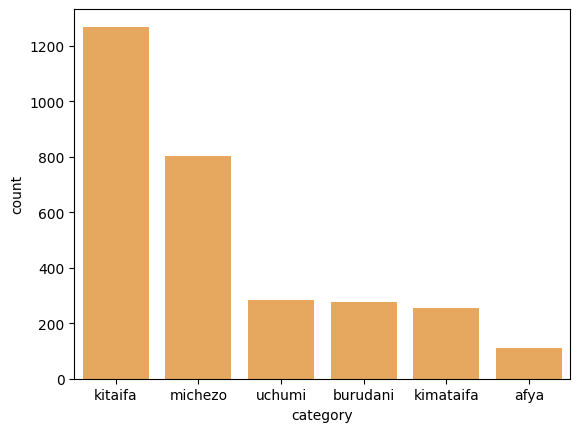

In [ ]:
sns.countplot(
    x="category",
    data=swahili_news,
    color="#fdaa48",
    order=swahili_news["category"].value_counts().index
    )

<Axes: xlabel='category', ylabel='count'>

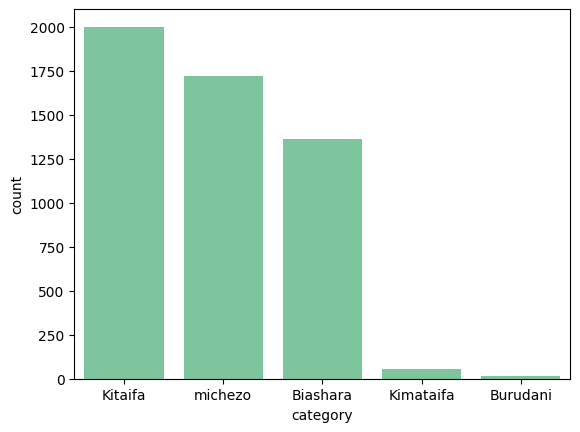

In [ ]:
sns.countplot(
    x="category",
    data=holdout_train,
    color="#72d09c",
    order=holdout_train["category"].value_counts().index
    )

In [ ]:
holdout_train[holdout_train["content"] == str(swahili_news.loc[1, "content"].lower().rstrip().lstrip())]

,id,content,category


In [ ]:
# set(holdout_train["id"].unique().tolist()) - set(swahili_news["id"].unique().tolist())

In [ ]:
len(set(holdout_train["id"].unique().tolist()) & set(swahili_news["id"].unique().tolist()))

510

In [ ]:
# swahili_news[swahili_news["id"].isin(list(set(holdout_train["id"].unique().tolist()) & set(swahili_news["id"].unique().tolist())))]

In [ ]:
# holdout_train[holdout_train["id"].isin(list(set(holdout_train["id"].unique().tolist()) & set(swahili_news["id"].unique().tolist())))]

In [ ]:
# merge the datasets
merged_swahili_news = pd.concat([swahili_news, holdout_train])

In [ ]:
swahili_news.shape[0] + holdout_train.shape[0]

8151

In [ ]:
# swahili_news[swahili_news["category"] == "kitaifa"].head()

In [ ]:
holdout_train[holdout_train["category"] == "kitaifa"].head()

,id,content,category


In [ ]:
[news for news in swahili_news["content"].tolist() if "serikali imesema haitakuwa" in news]

[]

In [ ]:
merged_swahili_news["category"].unique()

array(['uchumi', 'kitaifa', 'michezo', 'kimataifa', 'burudani', 'afya',
       'Kitaifa', 'Biashara', 'Kimataifa', 'Burudani'], dtype=object)

In [ ]:
# merged_swahili_news[merged_swahili_news["content"].duplicated()].loc[0, "content"]

In [ ]:
# merged_swahili_news[merged_swahili_news["content"] == "serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema shehe alhad.semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa."]

In [ ]:
# tokenizer.tokenize(merged_swahili_news[merged_swahili_news["content"] == "serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema shehe alhad.semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa."]["content"])

In [ ]:
def text_preprocessing(text):
    text = text.lower().rstrip().lstrip()
    return re.sub(r'[.,\'\[\]]', '', text)

merged_swahili_news[["content", "category"]] = merged_swahili_news[["content", "category"]].map(text_preprocessing)
merged_swahili_news.head(1)

,id,content,category
0,SW4670,bodi ya utalii tanzania (ttb) imesema itafanya misafara ya kutangaza utalii kwenye miji minne nchini china kati ya juni 19 hadi juni 26 mwaka huumisafara hiyo itatembelea miji ya beijing juni 19 shanghai juni 21 nanjig juni 24 na changsha juni 26mwenyekiti wa bodi ttb jaji mstaafu thomas mihayo ameyasema hayo kwenye mkutano na waandishi wa habari jijini dar es salaam“tunafanya jitihada kuhakikisha tunavuna watalii wengi zaidi kutoka china hasa tukizingatia umuhimu wa soko la sekta ya utalii nchini” amesema jaji mihayonovemba 2018 ttb ilifanya ziara kwenye miji ya beijing shanghai chengdu guangzhou na hong kong kutangaza vivutio vya utalii sanjari kuzitangaza safari za ndege za air tanzaniaziara hiyo inaelezwa kuzaa matunda ikiwa ni pamoja na watalii zaidi ya 300 kuja nchini mei mwaka huu kutembelea vivutio vya utalii,uchumi


In [ ]:
merged_swahili_news.tail(1)

,id,content,category
5150,SW999,akizungumza mara baada ya kutiwa saini kwa makubaliano hayo jana jioni waziri wa nchi ofisi ya waziri mkuu tawala za mikoa na serikali za mitaa hawa ghasia alisema uwekezaji huo unatarajiwa kuleta manufaa kwa shirika hilo kwani uwekezaji wake pia utasaidia kutoa elimu kwa vitendo juu ya ufugaji kwa kada mbalimbalialisema miaka ya nyuma shirika hilo lilikuwa likisifika kwa ufugaji wa kuku kabla ya kusitisha shughuli hizo kutokana na uwepo wa sababu mbalimbali na kusababisha shirika hilo kukosa mapato yaliyokuwa yakitokana na uuzaji wa kuku na mayaimkurugenzi wa shirika la elimu kibaha cyprian mpemba alisema uwekezaji huo wa miaka 66 mbali na kuingizia shirika hilo kiasi cha sh milioni 100 kila mwaka pia utawawezesha kuvuna kiasi kingine kama hicho kama ada ya uingiaji katika eneo hiloalisema itachukua muda wa miaka nane hadi uwekezaji rasmi ukamilike katika eneo hilo ukihusisha idara mbalimbali ikiwemo ujenzi wa viwanda vya usindikaji wa nyama na utengenezaji wa soseji huku kila baada ya miaka miwili wakikamilisha ujenzi wa eneo yakiwemo maeneo ya kufugia kuku haompemba alisema matarajio baada ya mika miwili ijayo mradi huo utaweza kuzalisha kuku milioni 27 huku wakitoa ajira kwa watu 120 na ukikamilika utazalisha kuku milioni 165 pamoja na kutoa ajira kwa watu 700 hatua aliyosema itasaidia kuleta mapinduzi katika ufugaji wa kuku hapa nchini sambamba na kutoa elimu kwa wanafunzi kutoka vyuo mbalimbalinaye mtendaji mkuu wa kampuni hiyo hesham ewies alisema malengo yao ni kuibadilisha kibaha kwa muda mfupi kwa kulifanya kuwa eneo linalosifika kutokana na shughuli za ufugaji wa kuku huku zaidi wakilenga kuondoa upungufu wa mahitaji ya bidhaa ya kuku yaliyopo kwa sasa nchinialisema watarajio yao baada ya miaka michache ijayo tanzania itaweza kusifika kwa usafirishaji wa bidhaa zitokanazo na kuku kwenda nje ya nchi na hivyo kuliongeza taifa mapato,biashara


In [ ]:
merged_swahili_news[merged_swahili_news["content"].duplicated()].shape[0]

608

In [ ]:
merged_swahili_news[~merged_swahili_news["content"].duplicated()].shape[0]

7543

In [ ]:
merged_swahili_news[merged_swahili_news["content"].duplicated()].shape[0] + merged_swahili_news[~merged_swahili_news["content"].duplicated()].shape[0]

8151

In [ ]:
merged_swahili_news.shape

(8151, 3)

In [ ]:
print(f"{(merged_swahili_news[merged_swahili_news["content"].duplicated()].shape[0] / merged_swahili_news.shape[0]) * 100:.2f}% of the merged data set is duplicated.")

7.46% of the merged data set is duplicated.


In [ ]:
merged_swahili_news = merged_swahili_news[~merged_swahili_news["content"].duplicated()]

In [ ]:
# tokenizer = AutoTokenizer.from_pretrained("Benjamin-png/bert-tokenizer-swahili")

# model = AutoModelForTokenClassification.from_pretrained("castorini/afriberta_base")
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
masakhane_tokenizer = AutoTokenizer.from_pretrained("Davlan/afro-xlmr-base")
swah_tokenizer = AutoTokenizer.from_pretrained("Benjamin-png/swahili-mms-tts-finetuned")
# tokenizer.model_max_length = 512


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


inputs = tokenizer(
    # padding=True,
    stride=50,
    return_overflowing_tokens=True
)

def tokenize(text):
    encoding = tokenizer(
        text,
        max_length=512,
        truncation=True,
        stride=128,
        return_overflowing_tokens=True,
        padding="max_length"
    )
    return encoding["input_ids"]

In [ ]:
print("Tokenizing using xlm roberta..")

def tokenize(text):
    # tokens = tokenizer.tokenize(text)
    encoding = tokenizer(
                    text,
                    max_length=512,
                    truncation=True,
                    # stride=128,
                    return_overflowing_tokens=True,
                    padding="max_length"
                    )
    tokens = [tokenizer.convert_ids_to_tokens(ids) for ids in encoding["input_ids"]][0]
    token_ids = encoding["input_ids"][0]
    return tokens, token_ids

merged_swahili_news["tokenized"] = merged_swahili_news["content"].apply(lambda x: tokenize(x)[0])
merged_swahili_news["token_ids"] = merged_swahili_news["content"].apply(lambda x: tokenize(x)[1])

print("Now tokenizing using masakhane...")

# def masakhane_tokenize(text):
#     encoding = masakhane_tokenizer(
#                     text,
#                     max_length=512,
#                     truncation=True,
#                     stride=128,
#                     return_overflowing_tokens=True,
#                     padding="max_length"
#                     )
#     tokens = [masakhane_tokenizer.convert_ids_to_tokens(ids) for ids in encoding["input_ids"]][0]
#     token_ids = encoding["input_ids"]
#     return tokens, token_ids

# merged_swahili_news["masakhane_tokenized"] = merged_swahili_news["content"].apply(lambda x: masakhane_tokenize(x)[0])
# merged_swahili_news["masakhane_token_ids"] = merged_swahili_news["content"].apply(lambda x: masakhane_tokenize(x)[1])

# print("Working on tokenizing using SwahBERT...")

# def swah_tokenize(text):
#     encoding = swah_tokenizer(
#                     text,
#                     max_length=512,
#                     truncation=True,
#                     stride=128,
#                     return_overflowing_tokens=True,
#                     padding="max_length"
#                     )
#     tokens = [swah_tokenizer.convert_ids_to_tokens(ids) for ids in encoding["input_ids"]]
#     token_ids = encoding["input_ids"]
#     return tokens, token_ids

# merged_swahili_news["swah_tokenized"] = merged_swahili_news["content"].apply(lambda x: swah_tokenize(x)[0])
# merged_swahili_news["swah_token_ids"] = merged_swahili_news["content"].apply(lambda x: swah_tokenize(x)[1])

Tokenizing using xlm roberta..
Now tokenizing using masakhane...


In [ ]:
# merged_swahili_news.head(1)

In [ ]:
# merged_swahili_news.loc[0, ["token_ids", "masakhane_token_ids"]]

In [ ]:
merged_swahili_news["content"].loc[0]

,content
0,bodi ya utalii tanzania (ttb) imesema itafanya misafara ya kutangaza utalii kwenye miji minne nchini china kati ya juni 19 hadi juni 26 mwaka huumisafara hiyo itatembelea miji ya beijing juni 19 shanghai juni 21 nanjig juni 24 na changsha juni 26mwenyekiti wa bodi ttb jaji mstaafu thomas mihayo ameyasema hayo kwenye mkutano na waandishi wa habari jijini dar es salaam“tunafanya jitihada kuhakikisha tunavuna watalii wengi zaidi kutoka china hasa tukizingatia umuhimu wa soko la sekta ya utalii nchini” amesema jaji mihayonovemba 2018 ttb ilifanya ziara kwenye miji ya beijing shanghai chengdu guangzhou na hong kong kutangaza vivutio vya utalii sanjari kuzitangaza safari za ndege za air tanzaniaziara hiyo inaelezwa kuzaa matunda ikiwa ni pamoja na watalii zaidi ya 300 kuja nchini mei mwaka huu kutembelea vivutio vya utalii
0,serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani kabila au itikadi yoyotehayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zaonaibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote” amesema masauniakizungumza wakati wa ufunguzi huo shehe wa mkoa wa dar es salaam alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii” amesema shehe alhadsemina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa


In [ ]:
merged_swahili_news["token_length"] = merged_swahili_news["tokenized"].apply(lambda x: len(x))

pd.concat([merged_swahili_news[["token_length"]].sort_values(by="token_length").head(), merged_swahili_news[["token_length"]].sort_values(by="token_length").tail()])

,token_length
5142,512
5141,512
5140,512
5139,512
5138,512
5147,512
5148,512
5149,512
5150,512
0,512


In [ ]:
# merged_swahili_news["masakhane_token_length"] = merged_swahili_news["masakhane_tokenized"].apply(lambda x: len(x))

# pd.concat([merged_swahili_news[["masakhane_token_length"]].sort_values(by="masakhane_token_length").head(), merged_swahili_news[["masakhane_token_length"]].sort_values(by="masakhane_token_length").tail()])

In [ ]:
merged_swahili_news[merged_swahili_news["token_length"] == 0]

,id,content,category,tokenized,token_ids,token_length


In [ ]:
merged_swahili_news[merged_swahili_news["token_length"] == 0]["id"].tolist()

[]

In [ ]:
# merged_swahili_news[merged_swahili_news["token_length"] < 10]

In [ ]:
# merged_swahili_news[merged_swahili_news["content"] == "serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema shehe alhad.semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa."]

In [ ]:
# merged_swahili_news.loc[5493, "tokenized"]

In [ ]:
# merged_swahili_news.head(1)

In [ ]:
merged_swahili_news["token_length"] = merged_swahili_news["tokenized"].apply(lambda x: len(x))

In [ ]:
print(f"{round(merged_swahili_news[merged_swahili_news["token_length"] > 512].shape[0]/merged_swahili_news.shape[0] * 100, 2)}% of data has more than 512 tokens while {round(merged_swahili_news[merged_swahili_news["token_length"] <= 512].shape[0]/merged_swahili_news.shape[0] * 100, 2)}% has less than 512 tokens.")

0.0% of data has more than 512 tokens while 100.0% has less than 512 tokens.


In [ ]:
merged_swahili_news[merged_swahili_news["token_length"] > 512].shape[0]/merged_swahili_news.shape[0] * 100

0.0

In [ ]:
merged_swahili_news[merged_swahili_news["id"].isin(merged_swahili_news[merged_swahili_news["token_length"] > 512]["id"].unique().tolist())].head(1)

,id,content,category,tokenized,token_ids,token_length


In [ ]:
merged_swahili_news_length = merged_swahili_news["token_ids"].str.len().max()
merged_swahili_news_length

512

In [ ]:
le = LabelEncoder()
merged_swahili_news["target"] = le.fit_transform(merged_swahili_news["category"])

In [ ]:
train_merged_swahili_news, test_merged_swahili_news = train_test_split(
                                                        merged_swahili_news,
                                                        train_size=.8,
                                                        random_state=42
                                                        )

train_merged_swahili_news, validation_merged_swahili_news = train_test_split(
                                                                train_merged_swahili_news,
                                                                train_size=0.9,
                                                                random_state=42,
                                                                stratify=train_merged_swahili_news["category"]
                                                                )

In [ ]:
print(f"Training data has {train_merged_swahili_news.shape[0]} rows, testing data has {test_merged_swahili_news.shape[0]} rows and the validation data has {validation_merged_swahili_news.shape[0]} rows.")

Training data has 5430 rows, testing data has 1509 rows and the validation data has 604 rows.


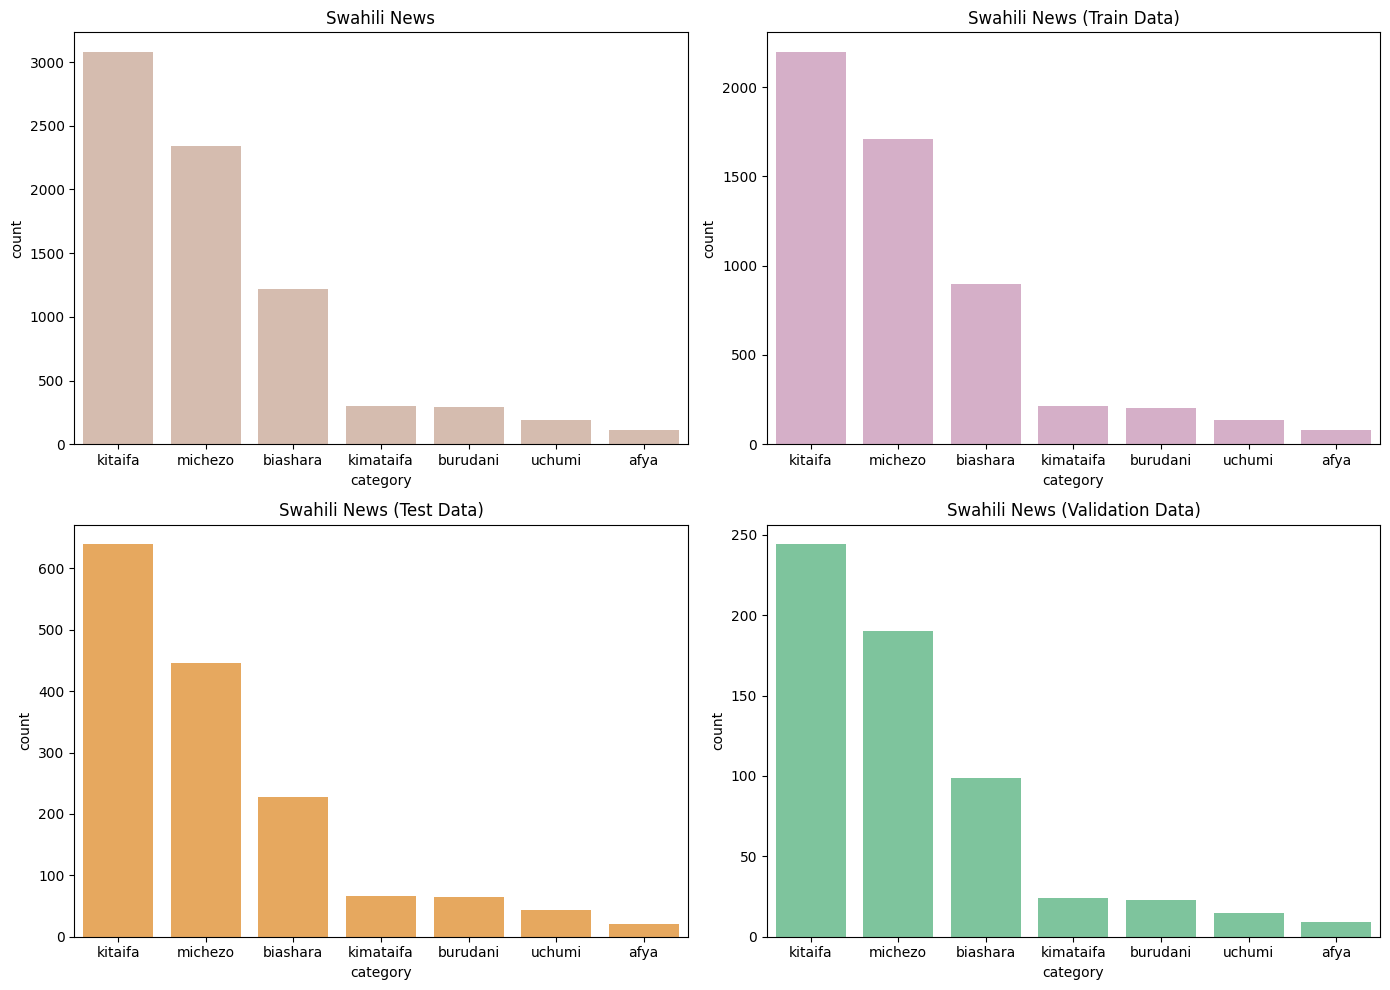

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14,10))

sns.countplot(
    x="category",
    data=merged_swahili_news,
    color="#dbbaa9",
    order=merged_swahili_news["category"].value_counts().index,
    ax=ax[0,0]
    ).set_title("Swahili News")

sns.countplot(
    x="category",
    data=train_merged_swahili_news,
    color="#dba9ca",
    order=train_merged_swahili_news["category"].value_counts().index,
    ax=ax[0,1]
    ).set_title("Swahili News (Train Data)")

sns.countplot(
    x="category",
    data=test_merged_swahili_news,
    color="#fdaa48",
    order=test_merged_swahili_news["category"].value_counts().index,
    ax=ax[1,0]
    ).set_title("Swahili News (Test Data)")

sns.countplot(
    x="category",
    data=validation_merged_swahili_news,
    color="#72d09c",
    order=validation_merged_swahili_news["category"].value_counts().index,
    ax=ax[1,1]
    ).set_title("Swahili News (Validation Data)")

plt.tight_layout()

In [ ]:
def collate(batch):
    samples, labels = zip(*batch)
    samples_padded = nn.utils.rnn.pad_sequence(samples, batch_first=True, padding_value=0)
    return samples_padded, torch.tensor(labels)

def inference_collate(batch):
    # samples = zip(*batch)
    samples_padded = nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=0)
    return samples_padded

class SamplesDataset(Dataset):
    def __init__(self, data):
        self.samples = data["token_ids"].values
        self.targets = data["target"].values

    def __getitem__(self, index):
        sample = self.samples[index]
        target = self.targets[index]
        # return target
        return torch.tensor(sample, dtype=torch.long), torch.tensor(target, dtype=torch.long)

    def __len__(self):
        return len(self.samples)

class InferenceSamplesDataset(Dataset):
    def __init__(self, data):
        self.samples = data["token_ids"].values

    def __getitem__(self, index):
        sample = self.samples[index]
        return torch.tensor(sample, dtype=torch.long)

    def __len__(self):
        return len(self.samples)

train_data = SamplesDataset(train_merged_swahili_news)
validation_data = SamplesDataset(validation_merged_swahili_news)

train_loader = DataLoader(train_data, collate_fn=collate, shuffle=True, batch_size=64)
validation_loader = DataLoader(validation_data, collate_fn=collate, shuffle=True, batch_size=64)

In [ ]:
merged_swahili_news["target"].nunique()

7

In [ ]:
# # Implementing LSTM

# class SamplesLSTMClassifier(nn.Module):
#     def __init__(self, vocab_size, dimension):
#         super().__init__()
#         self.dimension = dimension
#         self.vocab_size = vocab_size
#         self.lstm = nn.LSTM(
#             self.dimension,
#             self.dimension,
#             num_layers=2,
#             # dropout=0.3,
#             batch_first=True,
#             bidirectional=True,
#             )
#         self.dropout = nn.Dropout(0.3)
#         self.embedding = nn.Embedding(self.vocab_size, self.dimension, padding_idx=0)
#         self.classification = nn.Linear(self.dimension * 2, 7)

#     def forward(self,ins):
#         # ins = ins.squeeze(1)
#         embeddings = self.embedding(ins)
#         # print(f"Before LSTM: {embeddings.shape}")
#         output, (h_n, c_n) = self.lstm(embeddings)

#         h = torch.cat((h_n[-2], h_n[-1]), dim=1)
#         h = self.dropout(h)

#         return self.classification(h)
#         # return self.classification(h_n[-1])

In [ ]:
# max(max(chunk) for doc in merged_swahili_news["token_ids"] for chunk in doc) >= tokenizer.vocab_size

In [ ]:
merged_swahili_news.columns

Index(['id', 'content', 'category', 'tokenized', 'token_ids', 'token_length',
       'target'],
      dtype='object')

In [ ]:
merged_swahili_news["tokenized"].head(1)

,tokenized
0,"[<s>, ▁bod, i, ▁ya, ▁utal, ii, ▁tan, zania, ▁(, tt, b, ), ▁i, mesema, ▁ita, fanya, ▁mis, a, fara, ▁ya, ▁ku, tangaza, ▁utal, ii, ▁kwenye, ▁mij, i, ▁minne, ▁nchini, ▁, china, ▁kati, ▁ya, ▁juni, ▁19, ▁hadi, ▁juni, ▁26, ▁mwaka, ▁huu, mis, a, fara, ▁hiyo, ▁ita, tembelea, ▁mij, i, ▁ya, ▁bei, jing, ▁juni, ▁19, ▁s, hang, hai, ▁juni, ▁21, ▁na, nji, g, ▁juni, ▁24, ▁na, ▁, chang, sha, ▁juni, ▁26, m, wen, yek, iti, ▁wa, ▁bod, i, ▁, tt, b, ▁ja, ji, ▁m, staafu, ▁tho, mas, ▁mi, hay, o, ▁ame, y, asema, ▁hayo, ▁kwenye, ▁mkutano, ▁na, ▁waandishi, ▁wa, ▁habari, ▁jijini, ▁dar, ...]"


In [ ]:
vocab = {word for phrase in merged_swahili_news["tokenized"] for word in phrase}

In [ ]:
for sample, target in train_loader:
    print(target)
    # print(target.squeeze(1))
    print(f"Sample shape: {sample.shape}")
    print(f"Target shape: {target.shape}")
    print(target.ndim)
    break

tensor([4, 5, 4, 1, 2, 5, 1, 5, 5, 1, 4, 5, 4, 3, 1, 4, 5, 6, 4, 6, 2, 5, 4, 4,
        5, 1, 5, 3, 1, 4, 5, 1, 4, 3, 4, 2, 4, 4, 5, 5, 4, 5, 5, 5, 1, 5, 4, 5,
        5, 4, 4, 4, 4, 4, 1, 4, 5, 4, 5, 6, 4, 6, 4, 5])
Sample shape: torch.Size([64, 512])
Target shape: torch.Size([64])
1


In [ ]:
merged_swahili_news[merged_swahili_news["target"] == 4][["category", "target"]].head()

,category,target
1,kitaifa,4
4,kitaifa,4
5,kitaifa,4
6,kitaifa,4
9,kitaifa,4


In [ ]:
len(train_loader)

85

In [ ]:
len(merged_swahili_news)

7543

In [ ]:
for batch_X, batch_y in train_loader:
    print(batch_X.shape)
    print(batch_y.shape)
    break

torch.Size([64, 512])
torch.Size([64])


In [ ]:
# dimension = 512
# epochs = 10
# vocab_size = tokenizer.vocab_size

# lossFct = nn.CrossEntropyLoss()
# criterion = nn.CrossEntropyLoss()


# lstm_model = SamplesLSTMClassifier(vocab_size, dimension)
# optimizer = torch.optim.AdamW(lstm_model.parameters())

# losses = []
# val_losses = []

# best_val_loss = float("inf")
# patience = 3
# counter = 0
# for epoch in range(epochs):
#     lossAbs = 0
#     epoch_loss = 0
#     num_batch = 0
#     # counter = 0
#     progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

#     for sample, target in progress_bar:
#         # print(f"Sample count: {counter}")
#         outputs = lstm_model(sample)
#         loss = lossFct(outputs, target)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()
#         num_batch += 1
#         # counter+=1
#         progress_bar.set_postfix(loss=f"{epoch_loss/num_batch:.4f}")

#     losses.append(epoch_loss/num_batch)

#     lstm_model.eval()
#     val_loss = 0.0
#     correct = 0
#     total = 0
#     all_predictions = []
#     all_targets = []

#     with torch.no_grad():
#         for sample, target in validation_loader:
#             outputs = lstm_model(sample)
#             loss = criterion(outputs, target)
#             val_loss += loss.item()

#             preds = outputs.argmax(dim=1)
#             correct += (preds == target).sum().item()
#             total += target.size(0)

#             all_predictions.append(preds)
#             all_targets.append(target)

#     val_loss /= len(validation_loader)
#     val_acc = correct / total
#     val_losses.append(val_loss)

#     print(f"Epoch[{epoch+1}/{epochs}], Train Loss: {epoch_loss/num_batch:.4f}, Val Loss: {val_loss:.4f}")


#     # if val_loss < best_val_loss:
#     #     best_val_loss = val_loss
#     #     counter = 0
#     # else:
#     #     counter += 1

#     # if counter >= patience:
#     #     print(f"Early stopping at epoch {epoch+1} and saving the model")
#     #     torch.save({
#     #         "model_state_dict": lstm_model.state_dict(),
#     #         "vocab_size": vocab_size,
#     #         "dimension": dimension}, "best_model.pt")
#     #     break

#     # print(f"Epoch[{epoch+1}/{epochs}], Loss: {epoch_loss/num_batch}")

In [ ]:
# # plotting the training
# fig, ax = plt.subplots(1, 2, figsize=(8, 5))
# ax[0].plot(losses, color="#dba9b1")
# ax[0].set(title="Training Loss (LSTM)", xlabel="Epoch", ylabel="Loss")
# ax[1].plot(val_losses, color="#a9b1db")
# ax[1].set(title="Validation Loss (LSTM)", xlabel="Epoch", ylabel="Loss")

# plt.tight_layout()
# plt.show()

In [ ]:
#    # Concatenate all batches
# all_predictions = torch.cat(all_predictions)
# all_targets = torch.cat(all_targets)
# num_classes = 7

# precision_list = []
# recall_list = []
# f1_list = []

# for cls in range(num_classes):
#     tp = ((all_predictions == cls) & (all_targets == cls)).sum().item()
#     fp = ((all_predictions == cls) & (all_targets != cls)).sum().item()
#     fn = ((all_predictions != cls) & (all_targets == cls)).sum().item()
#     precision = tp / (tp + fp) if tp + fp > 0 else 0
#     recall = tp / (tp + fn) if tp + fn > 0 else 0
#     f1 = (
#         2 * precision * recall / (precision + recall)
#         if precision + recall > 0
#         else 0
#     )
#     precision_list.append(precision)
#     recall_list.append(recall)
#     f1_list.append(f1)

#     accuracy = correct / total
#     macro_precision = sum(precision_list) / num_classes
#     macro_recall = sum(recall_list) / num_classes
#     macro_f1 = sum(f1_list) / num_classes


In [ ]:
# print(f"Baseline LSTM\n----------\nAccuracy: {accuracy:.4f}\nF1 Score: {macro_f1:.4f}")

In [ ]:
# # Implementing self attention layer on LSTM

# class SamplesAttentionLSTMClassifier(nn.Module):
#     def __init__(self, vocab_size, dimension):
#         super().__init__()
#         self.dimension = dimension
#         self.vocab_size = vocab_size
#         self.lstm = nn.LSTM(
#             self.dimension,
#             self.dimension,
#             num_layers=2,
#             # dropout=0.3,
#             batch_first=True,
#             bidirectional=True,
#             )
#         self.attention = nn.Linear(self.dimension * 2, 1)
#         self.dropout = nn.Dropout(0.3)
#         self.embedding = nn.Embedding(self.vocab_size, self.dimension, padding_idx=0)
#         self.classification = nn.Linear(self.dimension * 2, 7)

#     def forward(self,ins):
#         # ins = ins.squeeze(1)
#         embeddings = self.embedding(ins)
#         # print(f"Before LSTM: {embeddings.shape}")
#         output, (h_n, c_n) = self.lstm(embeddings)

#         # attention scores
#         attn_scores = self.attention(output)

#         # [batch, seq_len]
#         attn_scores = attn_scores.squeeze(-1)

#         # normalize
#         attn_weights = nn.functional.softmax(attn_scores, dim=1)

#         # [batch, seq_len, 1]
#         attn_weights = attn_weights.unsqueeze(-1)

#         # weighted sum
#         context = torch.sum(attn_weights * output, dim=1)

#         # h = torch.cat((h_n[-2], h_n[-1]), dim=1)
#         context = self.dropout(context)

#         return self.classification(context)
#         # return self.classification(h_n[-1])

In [ ]:
# dimension = 512
# epochs = 10
# vocab_size = tokenizer.vocab_size

# lossFct = nn.CrossEntropyLoss()
# criterion = nn.CrossEntropyLoss()


# lstm_model = SamplesAttentionLSTMClassifier(vocab_size, dimension)
# optimizer = torch.optim.AdamW(lstm_model.parameters())

# losses = []
# val_losses = []

# best_val_loss = float("inf")
# patience = 3
# counter = 0
# for epoch in range(epochs):
#     lossAbs = 0
#     epoch_loss = 0
#     num_batch = 0
#     # counter = 0
#     progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

#     for sample, target in progress_bar:
#         # print(f"Sample count: {counter}")
#         outputs = lstm_model(sample)
#         loss = lossFct(outputs, target)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()
#         num_batch += 1
#         # counter+=1
#         progress_bar.set_postfix(loss=f"{epoch_loss/num_batch:.4f}")

#     losses.append(epoch_loss/num_batch)

#     lstm_model.eval()
#     val_loss = 0.0
#     correct = 0
#     total = 0
#     all_predictions = []
#     all_targets = []

#     with torch.no_grad():
#         for sample, target in validation_loader:
#             outputs = lstm_model(sample)
#             loss = criterion(outputs, target)
#             val_loss += loss.item()

#             preds = outputs.argmax(dim=1)
#             correct += (preds == target).sum().item()
#             total += target.size(0)

#             all_predictions.append(preds)
#             all_targets.append(target)

#     val_loss /= len(validation_loader)
#     val_acc = correct / total
#     val_losses.append(val_loss)

#     print(f"Epoch[{epoch+1}/{epochs}], Train Loss: {epoch_loss/num_batch:.4f}, Val Loss: {val_loss:.4f}")


#     # if val_loss < best_val_loss:
#     #     best_val_loss = val_loss
#     #     counter = 0
#     # else:
#     #     counter += 1

#     # if counter >= patience:
#     #     print(f"Early stopping at epoch {epoch+1} and saving the model")
#     #     torch.save({
#     #         "model_state_dict": lstm_model.state_dict(),
#     #         "vocab_size": vocab_size,
#     #         "dimension": dimension}, "best_model.pt")
#     #     break

#     # print(f"Epoch[{epoch+1}/{epochs}], Loss: {epoch_loss/num_batch}")

In [ ]:
# # Concatenate all batches
# all_predictions = torch.cat(all_predictions)
# all_targets = torch.cat(all_targets)
# num_classes = 7

# precision_list = []
# recall_list = []
# f1_list = []

# for cls in range(num_classes):
#     tp = ((all_predictions == cls) & (all_targets == cls)).sum().item()
#     fp = ((all_predictions == cls) & (all_targets != cls)).sum().item()
#     fn = ((all_predictions != cls) & (all_targets == cls)).sum().item()
#     precision = tp / (tp + fp) if tp + fp > 0 else 0
#     recall = tp / (tp + fn) if tp + fn > 0 else 0
#     f1 = (
#         2 * precision * recall / (precision + recall)
#         if precision + recall > 0
#         else 0
#     )
#     precision_list.append(precision)
#     recall_list.append(recall)
#     f1_list.append(f1)

#     accuracy = correct / total
#     macro_precision = sum(precision_list) / num_classes
#     macro_recall = sum(recall_list) / num_classes
#     macro_f1 = sum(f1_list) / num_classes


In [ ]:
# print(f"Attention w LSTM\n----------\nAccuracy: {accuracy:.4f}\nF1 Score: {macro_f1:.4f}")

In [ ]:
# # plotting the training
# fig, ax = plt.subplots(1, 2, figsize=(8, 5))
# ax[0].plot(losses, color="#dba9b1")
# ax[0].set(title="Training Loss (LSTM)", xlabel="Epoch", ylabel="Loss")
# ax[1].plot(val_losses, color="#a9b1db")
# ax[1].set(title="Validation Loss (LSTM)", xlabel="Epoch", ylabel="Loss")

# plt.tight_layout()
# plt.show()

In [ ]:
import psutil, torch
print(f"RAM available: {psutil.virtual_memory().available / 1e9:.1f} GB")
if torch.cuda.is_available():
    print(f"GPU VRAM free: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

RAM available: 9.3 GB


In [ ]:
# model_checkpoint = "castorini/afriteva_base"
# model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)
device = torch.device("cpu")
model = AutoModelForSequenceClassification.from_pretrained("castorini/afriberta_small", num_labels=7, low_cpu_mem_usage=True)
afriberta_tokenizer = AutoTokenizer.from_pretrained("castorini/afriberta_small")

afriberta_tokenizer.model_max_length = 512

model.to(device)

Loading weights:   0%|          | 0/69 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: castorini/afriberta_small
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=7, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(70006, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-3): 4 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linea

In [ ]:
# tokenize the dataset

def afriberta_tokenize(text):
    encoding = afriberta_tokenizer(
                    text,
                    max_length=512,
                    truncation=True,
                    stride=128,
                    return_overflowing_tokens=True,
                    padding="max_length"
                    )
    tokens = [afriberta_tokenizer.convert_ids_to_tokens(ids) for ids in encoding["input_ids"]][0]
    token_ids = encoding["input_ids"]
    return tokens, token_ids

merged_swahili_news["afriberta_tokenized"] = merged_swahili_news["content"].apply(lambda x: afriberta_tokenize(x)[0])

merged_swahili_news.head(2)

,id,content,category,tokenized,token_ids,token_length,target,afriberta_tokenized
0,SW4670,bodi ya utalii tanzania (ttb) imesema itafanya misafara ya kutangaza utalii kwenye miji minne nchini china kati ya juni 19 hadi juni 26 mwaka huumisafara hiyo itatembelea miji ya beijing juni 19 shanghai juni 21 nanjig juni 24 na changsha juni 26mwenyekiti wa bodi ttb jaji mstaafu thomas mihayo ameyasema hayo kwenye mkutano na waandishi wa habari jijini dar es salaam“tunafanya jitihada kuhakikisha tunavuna watalii wengi zaidi kutoka china hasa tukizingatia umuhimu wa soko la sekta ya utalii nchini” amesema jaji mihayonovemba 2018 ttb ilifanya ziara kwenye miji ya beijing shanghai chengdu guangzhou na hong kong kutangaza vivutio vya utalii sanjari kuzitangaza safari za ndege za air tanzaniaziara hiyo inaelezwa kuzaa matunda ikiwa ni pamoja na watalii zaidi ya 300 kuja nchini mei mwaka huu kutembelea vivutio vya utalii,uchumi,"[<s>, ▁bod, i, ▁ya, ▁utal, ii, ▁tan, zania, ▁(, tt, b, ), ▁i, mesema, ▁ita, fanya, ▁mis, a, fara, ▁ya, ▁ku, tangaza, ▁utal, ii, ▁kwenye, ▁mij, i, ▁minne, ▁nchini, ▁, china, ▁kati, ▁ya, ▁juni, ▁19, ▁hadi, ▁juni, ▁26, ▁mwaka, ▁huu, mis, a, fara, ▁hiyo, ▁ita, tembelea, ▁mij, i, ▁ya, ▁bei, jing, ▁juni, ▁19, ▁s, hang, hai, ▁juni, ▁21, ▁na, nji, g, ▁juni, ▁24, ▁na, ▁, chang, sha, ▁juni, ▁26, m, wen, yek, iti, ▁wa, ▁bod, i, ▁, tt, b, ▁ja, ji, ▁m, staafu, ▁tho, mas, ▁mi, hay, o, ▁ame, y, asema, ▁hayo, ▁kwenye, ▁mkutano, ▁na, ▁waandishi, ▁wa, ▁habari, ▁jijini, ▁dar, ...]","[0, 4486, 14, 151, 69243, 1573, 2197, 45725, 15, 3062, 275, 16, 17, 87035, 20973, 18357, 1239, 11, 64087, 151, 228, 51666, 69243, 1573, 5538, 10826, 14, 53807, 10790, 6, 42072, 23210, 151, 13645, 953, 24205, 13645, 1381, 9353, 11877, 2179, 11, 64087, 5748, 20973, 96341, 10826, 14, 151, 1079, 91577, 13645, 953, 91, 8467, 15251, 13645, 952, 24, 6942, 177, 13645, 744, 24, 6, 90965, 2420, 13645, 1381, 39, 11697, 21998, 1890, 259, 4486, 14, 6, 3062, 275, 79, 658, 347, 129637, 14461, 1510, 324, 12862, 31, 13721, 53, 52660, 19562, 5538, 52041, 24, 94525, 259, 17508, 36345, 1011, ...]",512,6,"[<s>, ▁bodi, ▁ya, ▁utalii, ▁tanzania, ▁(, tt, b, ), ▁imesema, ▁itafanya, ▁misa, fara, ▁ya, ▁kutangaza, ▁utalii, ▁kwenye, ▁miji, ▁minne, ▁nchini, ▁china, ▁kati, ▁ya, ▁ju, ni, ▁, 1, 9, ▁hadi, ▁ju, ni, ▁, 2, 6, ▁mwaka, ▁huu, misa, fara, ▁hiyo, ▁ita, tembelea, ▁miji, ▁ya, ▁be, ij, ing, ▁ju, ni, ▁, 1, 9, ▁shan, gha, i, ▁ju, ni, ▁, 2, 1, ▁na, nji, g, ▁ju, ni, ▁, 2, 4, ▁na, ▁, chang, sha, ▁ju, ni, ▁, 2, 6, mwenye, kiti, ▁wa, ▁bodi, ▁, tt, b, ▁, jaji, ▁mstaafu, ▁, th, oma, s, ▁mi, ha, yo, ▁ameyasema, ▁hayo, ▁kwenye, ▁mkutano, ▁na, ▁waandishi, ▁wa, ...]"
1,SW30826,pendo fundisha-mbeya rais dk john magufuri ametangaza kuwafukuza\nkazi wakurugenzi wote wa halmashauri ambao watabainika kukiuka sheria ya\nufutaji wa tozo za ushuru wa mazao alisema baada ya kuingia madarakani serikali\niliondoa tozo 80 miongoni mwa hizo tozo ushuru wakulima ambao walikuwa\nwakilipa mazao kutoka halmashauri moja kwenda nyingine rais dk magufuli aliyasema hayo juzi alipokuwa\nakiwahutubia wakazi wa wilaya ya kyela katika ziara ya kikazi ya siku 10 mkoani\nmbeya alisema sheria ya ufutaji wa tozo hizo\nzilipitishwa na bunge hivyo hakuna mtu yoyote wa kuitengua na kwamba mkurugenzi\natakaye itengua atakuwa umevunja sheria na anawajibu wa kufukuzwa kazi alisema licha ya kupitishwa kwa sheria hiyo wapo\nbaadhi ya watendaji wameendelea kuwatoza ushuru wananchi kwa kisingizio cha\nkupandisha ukusanyaji wa mapato hilo jambo sitaki kulisikia “wapo watendaji\nwanasema kufutwa kwa ushuru kunapunguza mapato narudia kwa viongozi wote wakurugenzi\nwatendaji wote wa halmashauri msiwatoze wananchi ushuru wa mzigo wowote usio\nzidi tani moja”alisema hata hivyo alitoa wito kwa watendaji kuzingatia\nsheria ya kuwalinda wakulima na ndio maana serikali iliziondoa tozo 80,kitaifa,"[<s>, ▁pe, ndo, ▁, fundisha, -, mbe, ya, ▁rais, ▁dk, ▁joh, n, ▁mag, u, furi, ▁ame, tangaza, ▁kuwa, fu, ku, za, ▁kazi, ▁wa, kurugenzi, ▁wote, ▁wa, ▁halmas

In [ ]:
train_merged_swahili_news["afriberta_tokenized"] = train_merged_swahili_news["content"].apply(lambda x: afriberta_tokenize(x)[0])
test_merged_swahili_news["afriberta_tokenized"] = test_merged_swahili_news["content"].apply(lambda x: afriberta_tokenize(x)[0])

train_merged_swahili_news.head(2)

,id,content,category,tokenized,token_ids,token_length,target,afriberta_tokenized
1200,SW23046,makamu wa rais wa shirikisho la mpira wa miguu nchini (tff) wallace karia ametuma salama hizo janakatika salamu zake kwa mwenyekiti mpya wa klabu hiyo dk twaha karia alisema anawapa pongezi kwa kuchaguliwa na kupewa heshima hiyo na wanachama wa coastal union katika kuitumikia klabu yao“kikubwa wanachopaswa kufanya kwa sasa ni kuodokana na makundi ya aina yoyote na kuifanya coastal union kuwa kitu kimoja na kujiandaa na msimu mpya wa ligi kuu ya vodacom” alisema kariaaidha karia alisema tff itashirikiana na uongozi mpya katika utendaji wa kazi na kuleta maendeleo katika mpira miguu nchiniklabu ya coastal union yenye makazi yake jijini tanga ilifanya uchaguzi wake mwishoni mwa wiki na kuwapata viongozi wake wapya akiwemo mwenyekiti makamu mwenyekiti na wajumbe wa kamati ya utendaji,michezo,"[<s>, ▁maka, mu, ▁wa, ▁rais, ▁wa, ▁, shiriki, sho, ▁la, ▁mpira, ▁wa, ▁mig, uu, ▁nchini, ▁(, t, ff, ), ▁wall, ace, ▁ka, ria, ▁amet, uma, ▁sa, lama, ▁hizo, ▁jana, ka, tika, ▁salam, u, ▁zake, ▁kwa, ▁mwenyekiti, ▁mpya, ▁wa, ▁klabu, ▁hiyo, ▁dk, ▁twa, ha, ▁ka, ria, ▁alisema, ▁an, awa, pa, ▁pong, ezi, ▁kwa, ▁ku, chaguliwa, ▁na, ▁ku, pewa, ▁heshima, ▁hiyo, ▁na, ▁wanachama, ▁wa, ▁coast, al, ▁union, ▁katika, ▁kui, tumikia, ▁klabu, ▁yao, “, ki, kub, wa, ▁wana, cho, pas, wa, ▁kufanya, ▁kwa, ▁sasa, ▁ni, ▁kuo, do, kana, ▁na, ▁makundi, ▁ya, ▁aina, ▁yoyote, ▁na, ▁kui, fanya, ▁coast, al, ▁union, ▁kuwa, ▁kitu, ▁ki, moja, ...]","[0, 2666, 561, 259, 40129, 259, 6, 48949, 11412, 21, 184037, 259, 1693, 17349, 10790, 15, 18, 4902, 16, 58982, 8509, 156, 1651, 2760, 4665, 57, 4580, 19712, 30938, 161, 8193, 41874, 34, 46717, 760, 235358, 39757, 259, 98863, 5748, 126920, 80059, 528, 156, 1651, 20205, 142, 7978, 763, 114007, 10779, 760, 228, 187132, 24, 228, 85922, 187170, 5748, 24, 136398, 259, 184085, 289, 69941, 1622, 1979, 225059, 98863, 26045, 155, 301, 75206, 634, 8971, 3089, 3166, 634, 20385, 760, 12926, 300, 20643, 246, 30082, 24, 174352, 151, 9116, 102939, 24, 1979, 18357, 184085, 289, 69941, 1922, 34707, 200, 70319, ...]",512,5,"[<s>, ▁makamu, ▁wa, ▁rais, ▁wa, ▁shirikisho, ▁la, ▁mpira, ▁wa, ▁miguu, ▁nchini, ▁(, t, ff, ), ▁wa, lla, ce, ▁ka, ria, ▁ame, tuma, ▁salama, ▁hizo, ▁jana, katika, ▁salamu, ▁zake, ▁kwa, ▁mwenyekiti, ▁mpya, ▁wa, ▁klabu, ▁hiyo, ▁d, k, ▁twa, ha, ▁ka, ria, ▁alisema, ▁ana, wapa, ▁pongezi, ▁kwa, ▁kuchaguliwa, ▁na, ▁kupewa, ▁heshima, ▁hiyo, ▁na, ▁wanachama, ▁wa, ▁coast, al, ▁union, ▁katika, ▁ku, i, tumikia, ▁klabu, ▁yao, “, ki, kubwa, ▁wanacho, paswa, ▁kufanya, ▁kwa, ▁sasa, ▁ni, ▁ku, odo, kana, ▁na, ▁makundi, ▁ya, ▁aina, ▁yoyote, ▁na, ▁kuifanya, ▁coast, al, ▁union, ▁kuwa, ▁kitu, ▁kimoja, ▁na, ▁kujiandaa, ▁na, ▁msimu, ▁mpya, ▁wa, ▁ligi, ▁kuu, ▁ya, ▁, vo, da, com, ...]"
1503,SW2683,mabingwa watetezi wa kombe la kagame azam fc leo wanashuka dimbani kupambana na mabingwa wa ligi kuu uganda vipers katika mchezo wa pili wa hatua ya makundi utakaochezwa kwenye uwanja wa azam complex chamazi azam ndiye kinara wa kundi a baada ya kushinda mchezo wa kwanza dhidi ya kator ya sudan kusini mabao 2-1 ikifuatiwa na jku yenye pointi moja baada ya kutoka sare ya bao 1-1 dhidi ya mabingwa wa uganda vipers wanaoshika nafasi ya tatu na kator wakiwa mkianimchezo huo huenda ukawa mgumu kwa sababu azam itahitaji kushinda ili kujihakikishia nafasi ya kuvuka hatua inayofuata lakini pia vipers itahitaji ushindi kujiweka pazuri aidha jku ya zanzibar itacheza dhidi ya kator ya sudan kusini saa 10 jioni kwenye uwanja wa azam complex kila mmoja anahitaji pointi tatu baada ya michezo yao ya kwanza kushindwa kuzipata na matokeo ya mechi hizo yataonesha picha nani atayaaga mashindano hayoni mchezo muhimu kwa jku kushinda ili kujiweka kwenye mazingira mazuri ya kusonga mbele ingawa pia yatatazamwa na vipers watakavyopata matokeo la sivyo michezo ya mwisho baada ya hiyo ndio itaamua mchezo mwingine mgumu ni rayon sport ya rwanda ikiwakaribisha gor mahia ya kenya kwenye uwanja wa taifa da

In [ ]:
test_merged_swahili_news.head(2)

,id,content,category,tokenized,token_ids,token_length,target,afriberta_tokenized
2558,SW13587,berlin ujerumani\n \n\n \n\tkansela wa ujerumani angela merkel amesema uingereza isiishi katika mawazo ya kufikirika kwamba itakuwa na haki zilezile kama wanachama wa umoja wa ulaya (eu) baada ya kujitoa kutoka chombo hicho\n \n\tmerkel ameyasema hayo bungeni hapa jana na kuongeza kuwa uingereza itakuwa kama mshirika tu na haitapata haki kama taifa mwanachama\n \n\ttaarifa hiyo ya merkel imekuja kabla ya mkutano utakaofanyika kesho kuhusu kujitoa kwa uingereza (brexit) mjini brussels ubelgiji\n \n\t“hii inawezekana kuonekana kama kujipendelea lakini ni lazima niseme wazi kwa sababu baadhi ya watu nchini uingereza wanaonekana kuwa na ndoto za mchana kuhusu suala hili\n \n\t“wapenzi ndugu zangu huenda mnaweza kufikiria kwamba hili ni jambo la kawaida tu lakini kwa bahati mbaya naweza kusema wazi napata hisia baadhi ya watu nchini uingereza wana mawazo ya kufikirika hii ni kupoteza muda” alisema merkel\n \n\talisema mazungumzo ya mwanzo kuhusu brexit ni lazima yajumuishe majukumu ya kifedha ya uingereza ikiwa ni pamoja na baada ya kujitoa kutoka umoja huo\n \n\tpia alisema masharti ya kujitoa kwa uingereza ni lazima yafikiwe katika njia inayoridhisha kabla ya majadiliano kuingia katika uhusiano mpya na umoja huo mtiririko ambao merkel ameuita kuwa usioweza kubadilishwa tena\n \n\tviongozi wa mataifa 27 wanachama wa eu watakutana kesho kuweka misingi ya umoja huo licha ya kwamba mazungumzo hayo yataanza rasmi juni mwaka huu,kimataifa,"[<s>, ▁berlin, ▁, uje, rum, ani, ▁kan, sela, ▁wa, ▁, uje, rum, ani, ▁angel, a, ▁mer, kel, ▁amesema, ▁u, inger, eza, ▁isi, ishi, ▁katika, ▁mawazo, ▁ya, ▁ku, fikiri, ka, ▁kwamba, ▁itakuwa, ▁na, ▁haki, ▁zile, zile, ▁kama, ▁wanachama, ▁wa, ▁um, oja, ▁wa, ▁u, laya, ▁(, eu, ), ▁baada, ▁ya, ▁kuji, toa, ▁kutoka, ▁cho, mbo, ▁hicho, ▁mer, kel, ▁ame, y, asema, ▁hayo, ▁bunge, ni, ▁hapa, ▁jana, ▁na, ▁kuongeza, ▁kuwa, ▁u, inger, eza, ▁itakuwa, ▁kama, ▁m, shi, rika, ▁tu, ▁na, ▁hai, ta, pata, ▁haki, ▁kama, ▁taifa, ▁mwana, cha, ma, ▁taarifa, ▁hiyo, ▁ya, ▁mer, kel, ▁ime, kuja, ▁kabla, ▁ya, ▁mkutano, ▁u, taka, o, fanyika, ...]","[0, 176788, 6, 1411, 1605, 2628, 203, 50416, 259, 6, 1411, 1605, 2628, 61909, 11, 1143, 2590, 36512, 75, 21228, 18904, 16252, 12787, 1622, 167156, 151, 228, 123514, 161, 10805, 134683, 24, 28005, 13719, 124510, 4268, 136398, 259, 286, 8508, 259, 75, 23987, 15, 4615, 16, 10181, 151, 23639, 11919, 10475, 681, 7567, 39385, 1143, 2590, 13721, 53, 52660, 19562, 121582, 93, 23810, 30938, 24, 92704, 1922, 75, 21228, 18904, 134683, 4268, 347, 3767, 14265, 370, 24, 1337, 102, 15026, 28005, 4268, 57055, 67391, 1436, 192, 34876, 5748, 151, 1143, 2590, 5431, 45884, 40823, 151, 52041, 75, 6758, 31, 51263, ...]",512,3,"[<s>, ▁, ber, lin, ▁u, jerumani, ▁kan, se, la, ▁wa, ▁u, jerumani, ▁ange, la, ▁, mer, kel, ▁amesema, ▁u, i, ngereza, ▁isi, ishi, ▁katika, ▁mawazo, ▁ya, ▁kufikiri, ka, ▁kwamba, ▁itakuwa, ▁na, ▁haki, ▁zile, zi, le, ▁kama, ▁wanachama, ▁wa, ▁umoja, ▁wa, ▁ulaya, ▁(, e, u, ), ▁baada, ▁ya, ▁kujitoa, ▁kutoka, ▁chombo, ▁hicho, ▁, mer, kel, ▁ameyasema, ▁hayo, ▁bungeni, ▁hapa, ▁jana, ▁na, ▁kuongeza, ▁kuwa, ▁u, i, ngereza, ▁itakuwa, ▁kama, ▁mshirika, ▁tu, ▁na, ▁haita, pata, ▁haki, ▁kama, ▁taifa, ▁mwanachama, ▁taarifa, ▁hiyo, ▁ya, ▁, mer, kel, ▁imekuja, ▁kabla, ▁ya, ▁mkutano, ▁utakaofanyika, ▁kesho, ▁kuhusu, ▁kujitoa, ▁kwa, ▁u, i, ngereza, ▁(, bre, xi, t, ), ▁mjini, ...]"
2863,SW4227,wazalishaji na wasambazaji wa taulo za kike wametakiwa kuunga mkono juhudi za serikali na wadau wengine kuwamkomboa wasichana dhidi ya vikwazo mbalimbali vya kielimu kwa kutopandisha bei ya bidhaa hizoakizungumza na gazeti hili jana mwenyekiti wa chama waandishi wa habari wanawake (tamwa) joyce shebe alieleza kusikitishwa na hatua ya wazalishaji kushindwa kupunguza bei licha ya serikali kuwafutia kodi ya ongezeko la thamani (vat) katika mwaka wa fedha 2018/19kutokana na kitendo hicho katika bajeti kuu ya mwaka 2019/20 iliyosomwa mwisho

In [ ]:
train_merged_swahili_news.head(1).reset_index(drop=True)

,id,content,category,tokenized,token_ids,token_length,target,afriberta_tokenized
0,SW23046,makamu wa rais wa shirikisho la mpira wa miguu nchini (tff) wallace karia ametuma salama hizo janakatika salamu zake kwa mwenyekiti mpya wa klabu hiyo dk twaha karia alisema anawapa pongezi kwa kuchaguliwa na kupewa heshima hiyo na wanachama wa coastal union katika kuitumikia klabu yao“kikubwa wanachopaswa kufanya kwa sasa ni kuodokana na makundi ya aina yoyote na kuifanya coastal union kuwa kitu kimoja na kujiandaa na msimu mpya wa ligi kuu ya vodacom” alisema kariaaidha karia alisema tff itashirikiana na uongozi mpya katika utendaji wa kazi na kuleta maendeleo katika mpira miguu nchiniklabu ya coastal union yenye makazi yake jijini tanga ilifanya uchaguzi wake mwishoni mwa wiki na kuwapata viongozi wake wapya akiwemo mwenyekiti makamu mwenyekiti na wajumbe wa kamati ya utendaji,michezo,"[<s>, ▁maka, mu, ▁wa, ▁rais, ▁wa, ▁, shiriki, sho, ▁la, ▁mpira, ▁wa, ▁mig, uu, ▁nchini, ▁(, t, ff, ), ▁wall, ace, ▁ka, ria, ▁amet, uma, ▁sa, lama, ▁hizo, ▁jana, ka, tika, ▁salam, u, ▁zake, ▁kwa, ▁mwenyekiti, ▁mpya, ▁wa, ▁klabu, ▁hiyo, ▁dk, ▁twa, ha, ▁ka, ria, ▁alisema, ▁an, awa, pa, ▁pong, ezi, ▁kwa, ▁ku, chaguliwa, ▁na, ▁ku, pewa, ▁heshima, ▁hiyo, ▁na, ▁wanachama, ▁wa, ▁coast, al, ▁union, ▁katika, ▁kui, tumikia, ▁klabu, ▁yao, “, ki, kub, wa, ▁wana, cho, pas, wa, ▁kufanya, ▁kwa, ▁sasa, ▁ni, ▁kuo, do, kana, ▁na, ▁makundi, ▁ya, ▁aina, ▁yoyote, ▁na, ▁kui, fanya, ▁coast, al, ▁union, ▁kuwa, ▁kitu, ▁ki, moja, ...]","[0, 2666, 561, 259, 40129, 259, 6, 48949, 11412, 21, 184037, 259, 1693, 17349, 10790, 15, 18, 4902, 16, 58982, 8509, 156, 1651, 2760, 4665, 57, 4580, 19712, 30938, 161, 8193, 41874, 34, 46717, 760, 235358, 39757, 259, 98863, 5748, 126920, 80059, 528, 156, 1651, 20205, 142, 7978, 763, 114007, 10779, 760, 228, 187132, 24, 228, 85922, 187170, 5748, 24, 136398, 259, 184085, 289, 69941, 1622, 1979, 225059, 98863, 26045, 155, 301, 75206, 634, 8971, 3089, 3166, 634, 20385, 760, 12926, 300, 20643, 246, 30082, 24, 174352, 151, 9116, 102939, 24, 1979, 18357, 184085, 289, 69941, 1922, 34707, 200, 70319, ...]",512,5,"[<s>, ▁makamu, ▁wa, ▁rais, ▁wa, ▁shirikisho, ▁la, ▁mpira, ▁wa, ▁miguu, ▁nchini, ▁(, t, ff, ), ▁wa, lla, ce, ▁ka, ria, ▁ame, tuma, ▁salama, ▁hizo, ▁jana, katika, ▁salamu, ▁zake, ▁kwa, ▁mwenyekiti, ▁mpya, ▁wa, ▁klabu, ▁hiyo, ▁d, k, ▁twa, ha, ▁ka, ria, ▁alisema, ▁ana, wapa, ▁pongezi, ▁kwa, ▁kuchaguliwa, ▁na, ▁kupewa, ▁heshima, ▁hiyo, ▁na, ▁wanachama, ▁wa, ▁coast, al, ▁union, ▁katika, ▁ku, i, tumikia, ▁klabu, ▁yao, “, ki, kubwa, ▁wanacho, paswa, ▁kufanya, ▁kwa, ▁sasa, ▁ni, ▁ku, odo, kana, ▁na, ▁makundi, ▁ya, ▁aina, ▁yoyote, ▁na, ▁kuifanya, ▁coast, al, ▁union, ▁kuwa, ▁kitu, ▁kimoja, ▁na, ▁kujiandaa, ▁na, ▁msimu, ▁mpya, ▁wa, ▁ligi, ▁kuu, ▁ya, ▁, vo, da, com, ...]"


In [ ]:
class AfribertaDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=512):
        self.texts = data["content"].reset_index(drop=True)
        self.labels = data["target"].reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = AfribertaDataset(train_merged_swahili_news, afriberta_tokenizer)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=64)

In [ ]:
for batch in train_loader:
  print(batch)
  break

{'input_ids': tensor([[    0,  1772,   268,  ...,     1,     1,     1],
        [    0,   394, 35614,  ...,     1,     1,     1],
        [    0,  1732, 18460,  ..., 37596,  9051,     2],
        ...,
        [    0,   261, 35392,  ...,   704,   261,     2],
        [    0, 13023,   395,  ...,   279,  3763,     2],
        [    0,  1225,   661,  ...,     1,     1,     1]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0]]), 'labels': tensor([2, 2, 5, 6, 4, 1, 4, 2, 4, 4, 4, 6, 4, 5, 4, 5, 5, 1, 4, 5, 5, 4, 1, 4,
        5, 4, 5, 5, 3, 4, 5, 1, 6, 5, 4, 4, 4, 4, 0, 4, 5, 4, 1, 5, 5, 3, 5, 5,
        5, 4, 5, 5, 5, 4, 4, 5, 1, 4, 4, 4, 4, 5, 5, 4])}


In [ ]:
# # Set format
# train_merged_swahili_news.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# # Data Loader
# data_loader = DataLoader(train_merged_swahili_news, batch_size=8, shuffle=True)


In [ ]:
# for batch in train_loader:
#     print(batch)
#     print(batch.ndim)
#     break

{'input_ids': tensor([[    0,  3508,   268,  ...,   261, 24588,     2],
        [    0, 13512, 24957,  ...,     1,     1,     1],
        [    0,  2366,   774,  ...,     1,     1,     1],
        ...,
        [    0,  2060,   268,  ...,   403,   300,     2],
        [    0,  2899,  1089,  ...,     1,     1,     1],
        [    0, 32002, 12474,  ...,     1,     1,     1]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), 'labels': tensor([5, 1, 5, 5, 4, 1, 4, 5, 5, 2, 5, 5, 5, 0, 4, 4, 5, 4, 5, 4, 5, 3, 4, 5,
        4, 5, 5, 1, 1, 4, 1, 4, 5, 5, 3, 4, 2, 1, 4, 5, 4, 4, 5, 5, 5, 4, 0, 4,
        4, 1, 1, 1, 5, 4, 4, 4, 4, 4, 4, 1, 4, 5, 5, 4])}


AttributeError: 'dict' object has no attribute 'ndim'

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
epochs = 15
losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

    for batch in progress_bar:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=f"{epoch_loss/len(train_loader):.4f}")

    losses.append(epoch_loss / len(train_loader))
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {losses[-1]:.4f}")

Epoch [1/15]:   0%|          | 0/85 [00:00<?, ?it/s]

In [ ]:
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# model.to(device)

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

In [ ]:
# dataset.set_format(
#     type="torch",
#     columns=["input_ids", "attention_mask", "label"]
# )

In [ ]:
model.train()

for epoch in range(3):

    total_loss = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=inputs,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

In [ ]:
batch = next(iter(train_loader))
print(type(batch))

In [ ]:
batch = next(iter(train_loader))

print(type(batch))

if isinstance(batch, dict):
    print(batch.keys())

    for key, value in batch.items():
        print(key, value.shape)

else:
    print(batch)